In [16]:
import kagglehub
import os
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Download/Path
path = kagglehub.dataset_download("gpiosenka/sports-classification")

print("Path to dataset files:", path)

# 2. Load Metadata
train_csv = os.path.join(path, "sports.csv")
df = pd.read_csv(train_csv)

# The 'labels' column contains the target classes
# The 'filepaths' column contains the image names (relative to 'path')

# 3. Configuration
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32
# data_dir = os.path.join(path, "train") # This is not needed anymore as filepaths are relative to 'path'

# 4. Create Data Generators
# We use ImageDataGenerator because images are not sorted into folders by class
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_ds = datagen.flow_from_dataframe(
    dataframe=df,
    directory=path, # Changed directory to 'path' (root of dataset)
    x_col="filepaths",
    y_col="labels",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=123
)

val_ds = datagen.flow_from_dataframe(
    dataframe=df,
    directory=path, # Changed directory to 'path' (root of dataset)
    x_col="filepaths",
    y_col="labels",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=123
)

print(f"Found {len(train_ds.class_indices)} classes.")

Using Colab cache for faster access to the 'sports-classification' dataset.
Path to dataset files: /kaggle/input/sports-classification
Found 11594 validated image filenames belonging to 100 classes.
Found 2898 validated image filenames belonging to 100 classes.
Found 100 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:918: UserWarning: Found 1 invalid image filename(s) in x_col="filepaths". These filename(s) will be ignored.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:918: UserWarning: Found 1 invalid image filename(s) in x_col="filepaths". These filename(s) will be ignored.
  warnings.warn(


In [17]:
import os

# List the contents of the downloaded dataset directory
print(f"Contents of {path}:")
for root, dirs, files in os.walk(path):
    for name in files:
        print(os.path.join(root, name))
    for name in dirs:
        print(os.path.join(root, name))

Streaming output truncated to the last 5000 lines.
/kaggle/input/sports-classification/train/rings/072.jpg
/kaggle/input/sports-classification/train/rings/111.jpg
/kaggle/input/sports-classification/train/rings/017.jpg
/kaggle/input/sports-classification/train/rings/145.jpg
/kaggle/input/sports-classification/train/rings/135.jpg
/kaggle/input/sports-classification/train/rings/088.jpg
/kaggle/input/sports-classification/train/rings/007.jpg
/kaggle/input/sports-classification/train/rings/057.jpg
/kaggle/input/sports-classification/train/rings/005.jpg
/kaggle/input/sports-classification/train/rings/121.jpg
/kaggle/input/sports-classification/train/rings/063.jpg
/kaggle/input/sports-classification/train/rings/070.jpg
/kaggle/input/sports-classification/train/rings/103.jpg
/kaggle/input/sports-classification/train/rings/004.jpg
/kaggle/input/sports-classification/train/rings/021.jpg
/kaggle/input/sports-classification/train/rings/126.jpg
/kaggle/input/sports-classification/train/rings/142.j

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │     3,211,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,274,148 (12.49 MB)

 Trainable params: 3,274,148 (12.49 MB)

 Non-trainable params: 0 (0.00 B)

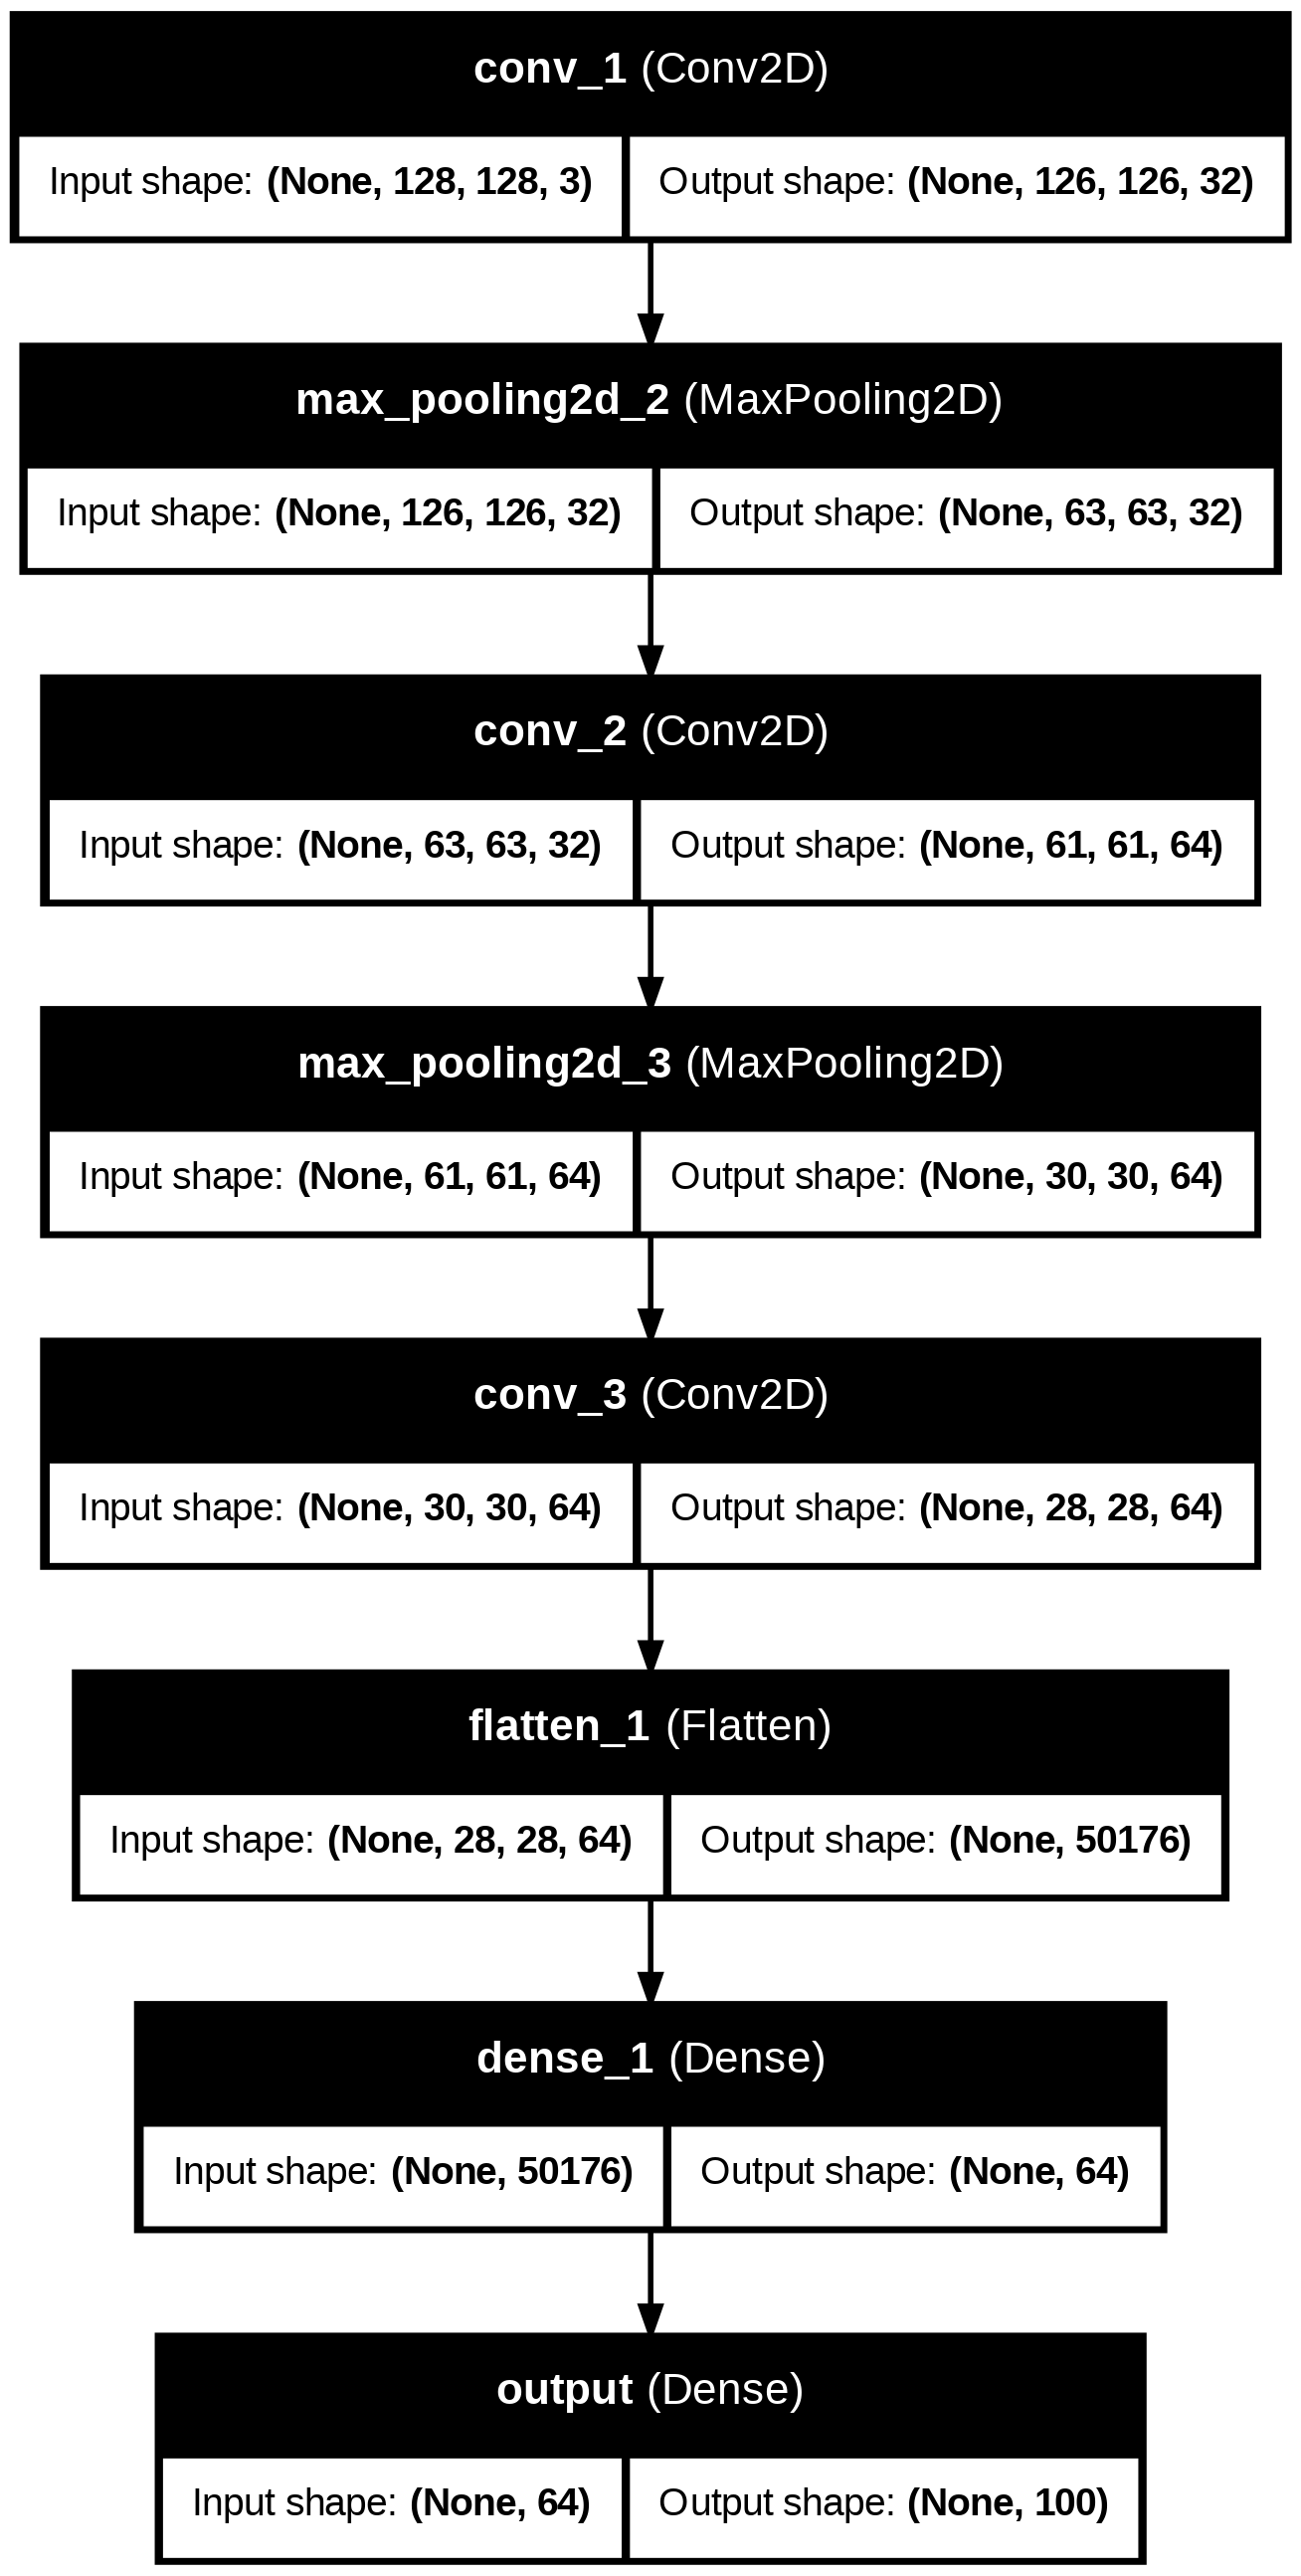

In [18]:
from tensorflow.keras import layers, models

# Define num_classes from the training generator
num_classes = len(train_ds.class_indices)

def create_model(num_classes):
    model = models.Sequential([
        layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

        # ImageDataGenerator already handles rescaling via the rescale=1./255 argument,
        # so we don't strictly need a Rescaling layer here, but it doesn't hurt.

        layers.Conv2D(32, (3, 3), activation='relu', name='conv_1'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu', name='conv_2'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu', name='conv_3'),
        layers.Flatten(),

        layers.Dense(64, activation='relu', name='dense_1'),

        layers.Dense(num_classes, activation='softmax', name='output')
    ])
    return model

model = create_model(num_classes)

# Using categorical_crossentropy because class_mode was 'categorical'
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# Draw architecture
tf.keras.utils.plot_model(model, show_shapes=True, show_layer_names=True)

In [ ]:
# Train the model for 10 epochs
epochs = 10
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

# Visualize training results
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(epochs)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()


Epoch 1/10
127/363 ━━━━━━━━━━━━━━━━━━━━ 2:02 517ms/step - accuracy: 0.0145 - loss: 4.6319

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, matthews_corrcoef

# 1. Re-create the validation generator with shuffle=False for evaluation
# This ensures y_true matches the order of y_pred
eval_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
eval_val_ds = eval_datagen.flow_from_dataframe(
    dataframe=df,
    directory=data_dir,
    x_col="filename",
    y_col="label",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=123
)

# 2. Get predictions
y_pred_probs = model.predict(eval_val_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# 3. Get the true labels
y_true = eval_val_ds.classes
class_labels = list(eval_val_ds.class_indices.keys())

# 4. Print metrics
print("Classification Report:\n", classification_report(y_true, y_pred, target_names=class_labels))
print("MCC:", matthews_corrcoef(y_true, y_pred))

# 5. Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=False, fmt='d', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Corrected Confusion Matrix (Validation Set)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()



In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# 1. Binarize y_true for multi-class ROC/PRC
# num_classes is 75 in this dataset
all_classes = list(range(num_classes))
y_true_bin = label_binarize(y_true, classes=all_classes)

plt.figure(figsize=(15, 6))

# 2. AUROC (Showing first 10 classes for clarity, or it will be too crowded)
plt.subplot(1, 2, 1)
for i in range(10):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    plt.plot(fpr, tpr, label=f'{class_labels[i]} (AUC={auc(fpr, tpr):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('AUROC (First 10 Classes)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# 3. AUPRC (First 10 classes)
plt.subplot(1, 2, 2)
for i in range(10):
    precision_vals, recall_vals, _ = precision_recall_curve(y_true_bin[:, i], y_pred_probs[:, i])
    ap_score = average_precision_score(y_true_bin[:, i], y_pred_probs[:, i])
    plt.plot(recall_vals, precision_vals, label=f'{class_labels[i]} (AP={ap_score:.2f})')
plt.title('AUPRC (First 10 Classes)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Ensure the model is built
model.build((None, IMG_HEIGHT, IMG_WIDTH, 3))

def get_gradcam(img_array, model, last_conv_layer_name, pred_index=None):
    # Reconstruct a functional model to access internal tensors safely in Keras 3
    inputs = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
    x = inputs
    target_layer_output = None

    # Iterate through the sequential layers to build a functional path
    for layer in model.layers:
        x = layer(x)
        if layer.name == last_conv_layer_name:
            target_layer_output = x

    grad_model = tf.keras.models.Model(inputs, [target_layer_output, x])

    # Track gradients
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # Gradient of the class wrt the conv layer output
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

# Prepare visualization data
eval_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
eval_val_ds = eval_datagen.flow_from_dataframe(
    dataframe=df,
    directory=data_dir,
    x_col="filename",
    y_col="label",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=123
)

# 1. Grab sample
x_batch, y_batch = next(eval_val_ds)
idx = 0
img = x_batch[idx:idx+1]
true_label_idx = np.argmax(y_batch[idx])
true_label_name = class_labels[true_label_idx]

# --- Saliency Map ---
img_tensor = tf.cast(img, tf.float32)
with tf.GradientTape() as tape:
    tape.watch(img_tensor)
    pred = model(img_tensor)
    top_pred_index = tf.argmax(pred[0])
    loss = pred[0, top_pred_index]
grads = tape.gradient(loss, img_tensor)
saliency = tf.reduce_max(tf.abs(grads), axis=-1)[0].numpy()

# --- Grad-CAM ---
heatmap = get_gradcam(img, model, 'conv_3')

# --- Visualization ---
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(img[0])
plt.title(f'True: {true_label_name}')

plt.subplot(1, 3, 2)
plt.imshow(saliency, cmap='hot')
plt.title('Saliency Map')

plt.subplot(1, 3, 3)
plt.imshow(img[0])
resized_heatmap = cv2.resize(heatmap, (IMG_WIDTH, IMG_HEIGHT))
plt.imshow(resized_heatmap, alpha=0.5, cmap='jet')
plt.title(f'Grad-CAM (Pred: {class_labels[top_pred_index]})')

plt.show()

